In [2]:
import sys
import os
from pathlib import Path

ROOT_DIR = Path("..").resolve()
os.chdir(ROOT_DIR)

if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from src.data_loader import load_data
from src.cleaning import DataCleaner

# Load and clean dataset
df_raw = load_data()
df = (
    DataCleaner(df_raw)
    .remove_duplicates()
    .clean_gender()
    .clean_city()
    .clean_monthly_charges()
    .clean_dates()
    .clean_negative_values()
    .fill_missing()
    .df
)

TARGET = "churn"
X = df.drop(columns=[TARGET, "customer_id", "full_name", "email", "phone", 
                     "date_of_birth", "customer_since", "last_login_date", "last_payment_date"], errors="ignore")
y = df[TARGET].map({"No": 0, "Yes": 1})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Load saved preprocessor
preprocessor = joblib.load("models/preprocessor.pkl")
X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)

In [3]:
log_reg = LogisticRegression(random_state=42, class_weight="balanced", max_iter=1000)
log_reg.fit(X_train_trans, y_train)

y_pred_lr = log_reg.predict(X_test_trans)
y_prob_lr = log_reg.predict_proba(X_test_trans)[:, 1]

print("--- LOGISTIC REGRESSION (BASELINE) ---")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

--- LOGISTIC REGRESSION (BASELINE) ---
              precision    recall  f1-score   support

           0       0.90      0.72      0.80     25972
           1       0.62      0.85      0.72     14028

    accuracy                           0.76     40000
   macro avg       0.76      0.78      0.76     40000
weighted avg       0.80      0.76      0.77     40000

ROC-AUC Score: 0.8251


In [4]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15],
    "min_samples_split": [2, 5]
}

rf = RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="recall",
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train_trans, y_train)
best_rf = grid_search.best_estimator_

y_pred_rf = best_rf.predict(X_test_trans)
y_prob_rf = best_rf.predict_proba(X_test_trans)[:, 1]

print("--- TUNED RANDOM FOREST ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

# Save final trained model
joblib.dump(best_rf, "models/churn_model.pkl")
print("\nSaved best model to models/churn_model.pkl!")

--- TUNED RANDOM FOREST ---
Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.90      0.83      0.87     25972
           1       0.73      0.83      0.78     14028

    accuracy                           0.83     40000
   macro avg       0.81      0.83      0.82     40000
weighted avg       0.84      0.83      0.83     40000

ROC-AUC Score: 0.8309

Saved best model to models/churn_model.pkl!


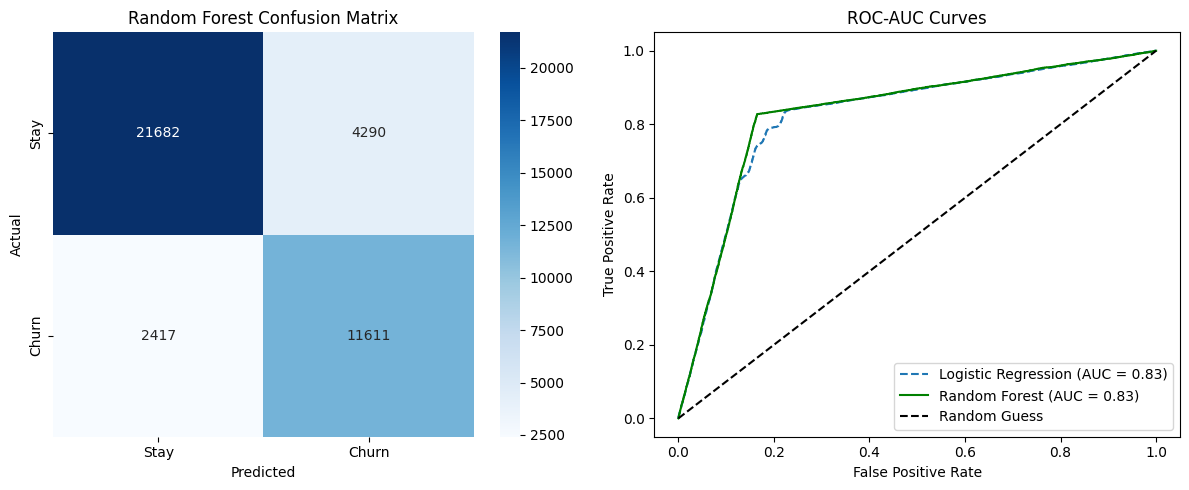

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Stay", "Churn"], yticklabels=["Stay", "Churn"])
axes[0].set_title("Random Forest Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

axes[1].plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.2f})", linestyle="--")
axes[1].plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.2f})", color="green")
axes[1].plot([0, 1], [0, 1], 'k--', label="Random Guess")
axes[1].set_title("ROC-AUC Curves")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
# Business Impact Parameters
total_customers = len(df)
annual_churn_rate = (df['churn'] == 'Yes').mean()
avg_annual_revenue_per_user = df['monthly_charges'].mean() * 12
retention_campaign_success_rate = 0.25  # 25% of reached churners are retained
model_recall = (y_pred_rf[y_test == 1] == 1).mean()

# Financial calculations
at_risk_customers = total_customers * annual_churn_rate
detected_churners = at_risk_customers * model_recall
retained_customers = detected_churners * retention_campaign_success_rate
revenue_saved = retained_customers * avg_annual_revenue_per_user

print("--- BUSINESS IMPACT & ROI REPORT ---")
print(f"Total Customer Base:                {total_customers:,}")
print(f"Annual Churn Rate:                  {annual_churn_rate * 100:.2f}%")
print(f"Average Annual Revenue per User:    ${avg_annual_revenue_per_user:,.2f}")
print(f"Predicted At-Risk Customers:        {int(detected_churners):,}")
print(f"Estimated Retained Customers:       {int(retained_customers):,}")
print(f"Estimated Revenue Retained:         ${revenue_saved:,.2f}")

--- BUSINESS IMPACT & ROI REPORT ---
Total Customer Base:                200,000
Annual Churn Rate:                  35.07%
Average Annual Revenue per User:    $6,848.66
Predicted At-Risk Customers:        58,054
Estimated Retained Customers:       14,513
Estimated Revenue Retained:         $99,398,258.05
